# Other offline learning algorithms

In [ ]:
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import gymnasium as gym


import d3rlpy
from d3rlpy.datasets import get_cartpole
from d3rlpy.algos import DQNConfig, TD3Config
from d3rlpy.metrics import TDErrorEvaluator, EnvironmentEvaluator

from pmind.replay import convert_rb_to_dataset


import bbrl_gymnasium

%load_ext autoreload
%autoreload 2

In [ ]:
ENV_NAME = (
    "CartPoleContinuous-v1",
    "Pendulum-v1",
    "MountainCarContinuous-v0",
    # "LunarLanderContinuous-v3",
)[2]
MODELS_DIR = f"../models/{ENV_NAME}/"
env = gym.make(ENV_NAME)

we will try those algos:

```py
d3rlpy.algos.BCConfig()
d3rlpy.algos.TD3PlusBCConfig()
d3rlpy.algos.TD3Config()
d3rlpy.algos.IQLConfig()
```

Note that BC ignores the reward.

In [5]:
# iql = d3rlpy.algos.IQLConfig().create()
# # NOTE: apparently, what they call an "epoch" here is not about a pass
# # through the whole dataset, but just a logging checkpoint
# offline_log = iql.fit(
#     dataset,
#     n_steps=20000,
#     n_steps_per_epoch=10000,
#     evaluators={"environment": d3rlpy.metrics.EnvironmentEvaluator(env, epsilon=0.001)},
# )

In [ ]:
# TODO: adapt config from TD3: nn architecture, action_scale, algo config...
rb_name = "rb-82"
rb = torch.load(MODELS_DIR + f"{rb_name}.pt", weights_only=False)

dataset = convert_rb_to_dataset(rb, contains_teleportation=True)

# Setup algorithm

model = d3rlpy.algos.IQLConfig(
    gamma= 0.99, # MC
    actor_learning_rate=1e-4, 
    critic_learning_rate=1e-4,
    batch_size=64,
    tau=0.05,
    # target_smoothing_clip=0.5,
    # target_smoothing_sigma=0.5
).create(device=None)

# Initialize NN with right obs and action dims
model.build_with_dataset(dataset)

# Setup metrics

# This metric suggests how Q functions overfit to training sets.
# If the TD error is large, the Q functions are overfitting.
# td_error_evaluator = TDErrorEvaluator(episodes=dataset.episodes)

env_evaluator = EnvironmentEvaluator(env)

rewards = env_evaluator(model, dataset=None)
print(f"Reward at initialization: {rewards}")

# Offline training
offline_log = model.fit(
    dataset,
    n_steps=50000,
    n_steps_per_epoch=1000,
    evaluators={
        # 'td_error': td_error_evaluator,
        'environment': env_evaluator
    }
    )

2026-04-27 16:36.37 [info     ] Signatures have been automatically determined. action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]) observation_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]) reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)])
2026-04-27 16:36.37 [info     ] Action-space has been automatically determined. action_space=<ActionSpace.CONTINUOUS: 1>
2026-04-27 16:36.37 [info     ] Action size has been automatically determined. action_size=1
Reward at initialization: -0.7919129395083113
2026-04-27 16:36.38 [info     ] dataset info                   dataset_info=DatasetInfo(observation_signature=Signature(dtype=[dtype('float32')], shape=[(2,)]), action_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), reward_signature=Signature(dtype=[dtype('float32')], shape=[(1,)]), action_space=<ActionSpace.CONTINUOUS: 1>, action_size=1)
2026-04-27 16:36.38 [warning  ] Skip building models since they're already built.
2026-04-27 16:36.38

Epoch 1/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-27 16:36.41 [info     ] IQL_20260427163638: epoch=1 step=1000 epoch=1 metrics={'time_sample_batch': 0.0004269866943359375, 'time_algorithm_update': 0.002580496072769165, 'critic_loss': 54.09245838237368, 'q_loss': 54.07543042110186, 'v_loss': 0.01702794782257297, 'actor_loss': 0.28530868800915776, 'time_step': 0.003051130771636963, 'environment': -68.37896705747532} step=1000
2026-04-27 16:36.41 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260427163638/model_1000.d3


Epoch 2/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-27 16:36.45 [info     ] IQL_20260427163638: epoch=2 step=2000 epoch=2 metrics={'time_sample_batch': 0.0004402282238006592, 'time_algorithm_update': 0.002741881847381592, 'critic_loss': 42.24994716014713, 'q_loss': 42.19077736733109, 'v_loss': 0.059169642502442, 'actor_loss': 0.05316987840505317, 'time_step': 0.003223868131637573, 'environment': -83.4636810200386} step=2000
2026-04-27 16:36.45 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260427163638/model_2000.d3


...

2026-04-27 16:39.05 [info     ] IQL_20260427163638: epoch=48 step=48000 epoch=48 metrics={'time_sample_batch': 0.00038434362411499026, 'time_algorithm_update': 0.002221401929855347, 'critic_loss': 26.884240365684033, 'q_loss': 26.692395636558533, 'v_loss': 0.19184476180840285, 'actor_loss': -0.4179854481816292, 'time_step': 0.0026426043510437013, 'environment': 7.695133997605899} step=48000
2026-04-27 16:39.05 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260427163638/model_48000.d3


Epoch 49/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-27 16:39.08 [info     ] IQL_20260427163638: epoch=49 step=49000 epoch=49 metrics={'time_sample_batch': 0.00037551498413085935, 'time_algorithm_update': 0.002165987491607666, 'critic_loss': 24.896432215288282, 'q_loss': 24.722159503355623, 'v_loss': 0.17427268105372787, 'actor_loss': -0.23622946145944299, 'time_step': 0.002576988935470581, 'environment': 14.842983681348016} step=49000
2026-04-27 16:39.08 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260427163638/model_49000.d3


Epoch 50/50:   0%|          | 0/1000 [00:00<?, ?it/s]

2026-04-27 16:39.10 [info     ] IQL_20260427163638: epoch=50 step=50000 epoch=50 metrics={'time_sample_batch': 0.00037211012840270995, 'time_algorithm_update': 0.002164909601211548, 'critic_loss': 26.35955979642272, 'q_loss': 26.18319660603255, 'v_loss': 0.17636325263697655, 'actor_loss': -0.19854637577012182, 'time_step': 0.0025723066329956055, 'environment': 20.961434689742962} step=50000
2026-04-27 16:39.10 [info     ] Model parameters are saved to d3rlpy_logs/IQL_20260427163638/model_50000.d3


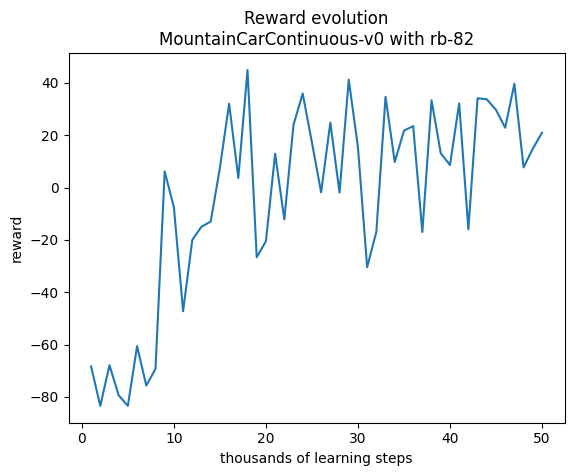

In [ ]:
epochs, logs = zip(*offline_log)
df_logs = pd.DataFrame(logs, index=epochs)
plt.plot(df_logs.index, df_logs.environment)
plt.title(f"Reward evolution\n{ENV_NAME} with {rb_name}")
plt.ylabel("reward")
plt.xlabel("thousands of learning steps")
plt.show()

In [8]:
action = model.predict(env.observation_space.sample().reshape(1,-1))
action

array([[0.9591421]], dtype=float32)

In [ ]:
#TODO: understand how to get the best policy...

0.99